# 🛍️ Customer Personality Analysis — Segmentation & Campaign Targeting

**Author:** Vusal Mammadzade · **GitHub:** [memmedzadev81-max](https://github.com/memmedzadev81-max)

A retailer runs marketing campaigns but most customers ignore them (only **14.9%** respond).
Blasting everyone wastes budget. The business question:

> **Who are our customers, which segments are worth targeting, and where is the marketing budget being wasted?**

This is a **senior-level** workflow: Cleaning → Feature Engineering → EDA →
**RFM Segmentation** → **K-Means Clustering** → Campaign Response Analysis → Statistical Tests → Strategy.

**Data:** 2,240 customers, 29 variables (demographics, 2 years of spending across 6 categories, 5 past campaigns).


## 1. Setup & Load

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"]=110
df = pd.read_csv("../data/marketing_campaign.csv")
print("Raw shape:", df.shape)
df.head(3)

Raw shape: (2240, 29)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0


## 2. Data Cleaning — with documented decisions

A senior analyst doesn't just call `dropna()`. Every decision is justified:

1. **Income** — 24 missing → fill with **median** (robust to the obvious `666,666` data-entry error).
2. **Income outlier** — cap at the 99th percentile so one bad row doesn't distort means.
3. **Age** — derived from `Year_Birth`; rows implying age > 100 (birth years 1893–1900) are removed as errors.
4. **Marital_Status** — junk labels (`YOLO`, `Absurd`, `Alone`) collapsed into clean categories.
5. **Constant columns** (`Z_CostContact`, `Z_Revenue`) dropped — they carry zero information.


In [2]:
df["Income"] = df["Income"].fillna(df["Income"].median())
cap = df["Income"].quantile(0.99)
df.loc[df["Income"] > cap, "Income"] = cap

df["Age"] = 2015 - df["Year_Birth"]
df = df[df["Age"] < 100]

df["Marital_Status"] = df["Marital_Status"].replace(
    {"Alone":"Single","Absurd":"Single","YOLO":"Single",
     "Together":"Partner","Married":"Partner","Divorced":"Single","Widow":"Single"})
df["Education"] = df["Education"].replace(
    {"2n Cycle":"Master","Graduation":"Graduate","Basic":"Undergraduate"})

df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"])
df["Tenure_days"] = (df["Dt_Customer"].max() - df["Dt_Customer"]).dt.days
df = df.drop(columns=["Z_CostContact","Z_Revenue","ID","Year_Birth"])
print("After cleaning:", df.shape)

After cleaning: (2237, 27)


## 3. Feature Engineering

Raw columns aren't decision-ready. We build the metrics a business actually uses:
**total spend, total purchases, number of children, total campaigns accepted.**

In [3]:
spend_cols = ["MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]
df["TotalSpend"]     = df[spend_cols].sum(axis=1)
df["Children"]       = df["Kidhome"] + df["Teenhome"]
df["HasChildren"]    = (df["Children"] > 0).astype(int)
df["TotalPurchases"] = df[["NumWebPurchases","NumCatalogPurchases","NumStorePurchases"]].sum(axis=1)
df["TotalAcceptedCmp"]=df[["AcceptedCmp1","AcceptedCmp2","AcceptedCmp3","AcceptedCmp4","AcceptedCmp5"]].sum(axis=1)

print(f"Avg age: {df['Age'].mean():.0f} | Avg income: ${df['Income'].mean():,.0f}")
print(f"Avg 2-yr spend: ${df['TotalSpend'].mean():,.0f} | Response rate: {df['Response'].mean()*100:.1f}%")

Avg age: 46 | Avg income: $51,740
Avg 2-yr spend: $606 | Response rate: 14.9%


## 4. Exploratory Data Analysis

### 4.1 What do customers actually buy?

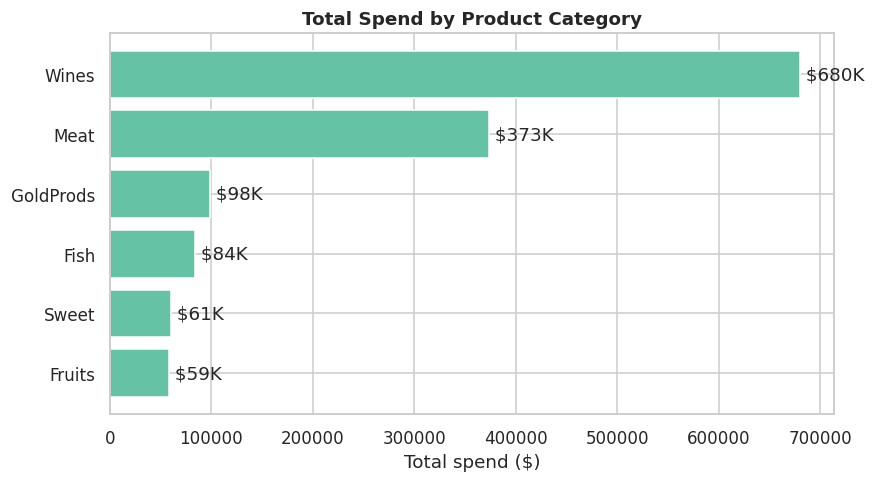

In [4]:
fig, ax = plt.subplots(figsize=(8.5,4.5))
cat = df[spend_cols].sum().sort_values()
labels=[c.replace('Mnt','').replace('Products','') for c in cat.index]
bars=ax.barh(labels, cat.values, color=sns.color_palette('Set2')[0])
ax.set_title('Total Spend by Product Category', weight='bold'); ax.set_xlabel('Total spend ($)')
for b,v in zip(bars,cat.values): ax.text(v,b.get_y()+b.get_height()/2,f' ${v/1000:.0f}K',va='center')
plt.show()

**Insight:** **Wine alone is ~50% of all spending.** This is a wine-led business — campaigns and bundles should be built around it.

### 4.2 The core driver: Income vs Spend

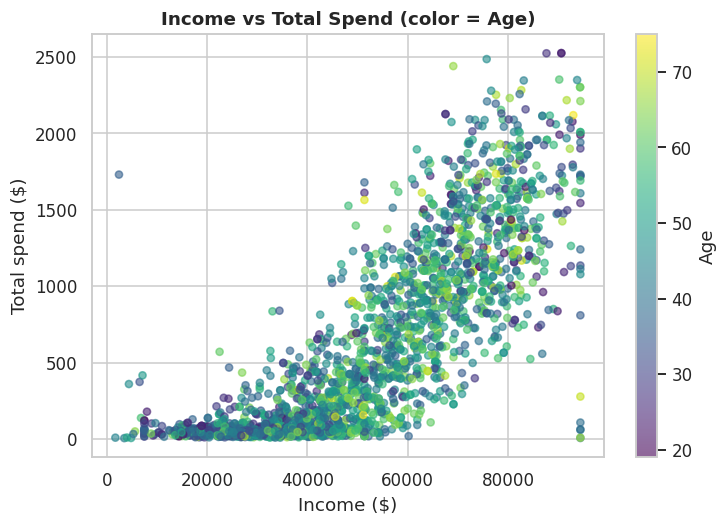

In [5]:
fig, ax = plt.subplots(figsize=(7.5,5))
sc=ax.scatter(df['Income'],df['TotalSpend'],c=df['Age'],cmap='viridis',alpha=0.6,s=22)
ax.set_title('Income vs Total Spend (color = Age)', weight='bold')
ax.set_xlabel('Income ($)'); ax.set_ylabel('Total spend ($)')
plt.colorbar(sc,label='Age'); plt.show()

**Insight:** Spend rises strongly with income (we confirm r = 0.81 later). Income is the single best predictor of customer value.

### 4.3 Do children change spending?

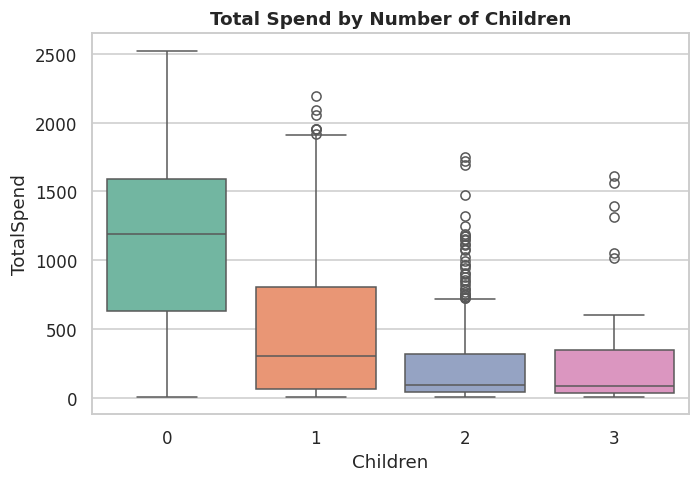

In [6]:
fig, ax = plt.subplots(figsize=(7,4.5))
sns.boxplot(data=df,x='Children',y='TotalSpend',hue='Children',palette='Set2',legend=False,ax=ax)
ax.set_title('Total Spend by Number of Children', weight='bold'); plt.show()

**Insight:** Customers **with no children spend far more.** Households with kids have less disposable income for wine/gourmet items — a key targeting filter.

## 5. RFM Segmentation

**RFM** scores every customer on three axes a business cares about:
- **Recency** — how recently they purchased (lower = better)
- **Frequency** — how many purchases (higher = better)
- **Monetary** — how much they spent (higher = better)

Each gets a 1–4 score; the sum (3–12) maps to a named segment.

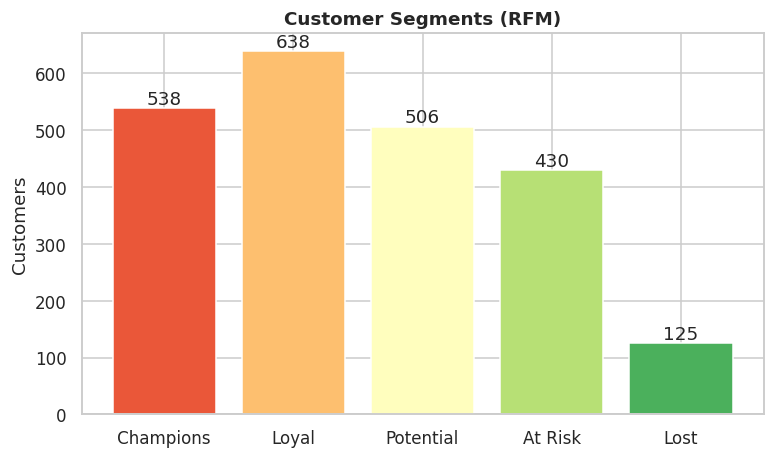

In [7]:
rfm = df[['Recency','TotalPurchases','TotalSpend']].copy()
rfm.columns=['Recency','Frequency','Monetary']
rfm['R']=pd.qcut(rfm['Recency'],4,labels=[4,3,2,1]).astype(int)
rfm['F']=pd.qcut(rfm['Frequency'].rank(method='first'),4,labels=[1,2,3,4]).astype(int)
rfm['M']=pd.qcut(rfm['Monetary'],4,labels=[1,2,3,4]).astype(int)
rfm['RFM_Score']=rfm[['R','F','M']].sum(axis=1)

def seg(s):
    if s>=10: return 'Champions'
    if s>=8:  return 'Loyal'
    if s>=6:  return 'Potential'
    if s>=4:  return 'At Risk'
    return 'Lost'
rfm['Segment']=rfm['RFM_Score'].apply(seg)
df['RFM_Segment']=rfm['Segment']

order=['Champions','Loyal','Potential','At Risk','Lost']
fig, ax = plt.subplots(figsize=(8,4.5))
s=rfm['Segment'].value_counts().reindex(order)
bars=ax.bar(s.index,s.values,color=sns.color_palette('RdYlGn_r',5)[::-1])
ax.set_title('Customer Segments (RFM)', weight='bold'); ax.set_ylabel('Customers')
for b,v in zip(bars,s.values): ax.text(b.get_x()+b.get_width()/2,v,f'{v}',ha='center',va='bottom')
plt.show()

### 5.1 Revenue & response concentration (the money question)

In [8]:
prof = df.groupby('RFM_Segment').agg(
        customers=('Response','size'),
        avg_spend=('TotalSpend','mean'),
        response_rate=('Response', lambda x: x.mean()*100),
        revenue=('TotalSpend','sum')).reindex(order)
prof['revenue_share_%'] = (prof['revenue']/prof['revenue'].sum()*100).round(1)
prof['response_rate']=prof['response_rate'].round(1)
prof['avg_spend']=prof['avg_spend'].round(0)
prof[['customers','avg_spend','response_rate','revenue_share_%']]

,customers,avg_spend,response_rate,revenue_share_%
RFM_Segment,,,,
Champions,538,1231.0,29.4,48.9
Loyal,638,847.0,15.8,39.9
Potential,506,222.0,11.1,8.3
At Risk,430,82.0,4.2,2.6
Lost,125,39.0,0.8,0.4


**Insight (the headline):**
- **Champions** are ~24% of customers but generate **~49% of all revenue** and respond to campaigns at **29%**.
- **Lost / At Risk** customers respond at **1–4%** — money spent marketing to them is mostly wasted.
This is a textbook Pareto pattern, and it dictates the entire strategy below.

## 6. K-Means Clustering (unsupervised cross-check)

RFM uses business rules. K-Means lets the **data** group customers by `Income`, `Spend`, `Age`.
We standardize first (so income's large scale doesn't dominate) and use 4 clusters.

,Income,TotalSpend,Age,TotalPurchases,Response
Cluster,,,,,
0,72103.1,1239.4,38.0,19.4,0.2
1,33108.0,135.3,37.5,6.7,0.1
2,45891.8,271.8,56.1,9.9,0.1
3,72494.4,1250.8,58.7,19.6,0.2


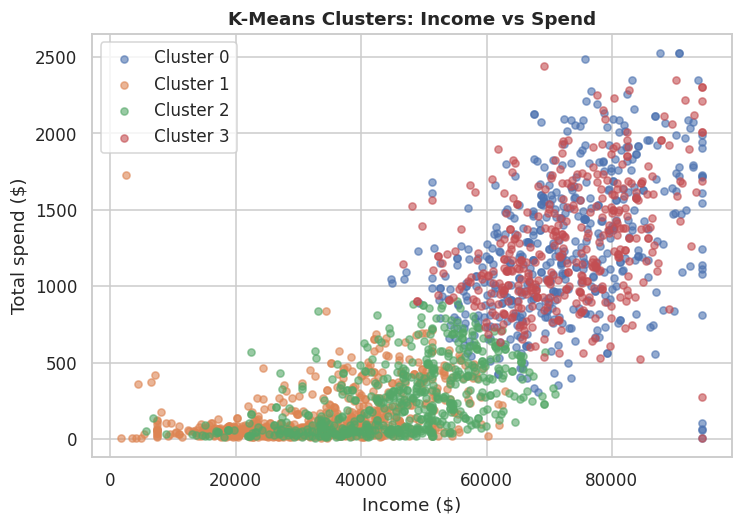

In [9]:
feat = df[['Income','TotalSpend','Age']].copy()
X = StandardScaler().fit_transform(feat)
df['Cluster'] = KMeans(n_clusters=4, random_state=42, n_init=10).fit_predict(X)

prof = df.groupby('Cluster')[['Income','TotalSpend','Age','TotalPurchases','Response']].mean().round(1)
display(prof)

fig, ax = plt.subplots(figsize=(7.5,5))
for c in sorted(df['Cluster'].unique()):
    sub=df[df['Cluster']==c]
    ax.scatter(sub['Income'],sub['TotalSpend'],label=f'Cluster {c}',alpha=0.6,s=22)
ax.set_title('K-Means Clusters: Income vs Spend', weight='bold')
ax.set_xlabel('Income ($)'); ax.set_ylabel('Total spend ($)'); ax.legend(); plt.show()

**Insight:** K-Means independently confirms RFM — it splits customers into a clear
**high-income / high-spend** group (~$72K income, ~$1,240 spend, 20% response) and
**low-income / low-spend** groups (~$33K, ~$135 spend, 10% response). Two methods, same story = a robust finding.

## 7. Campaign Response by Segment

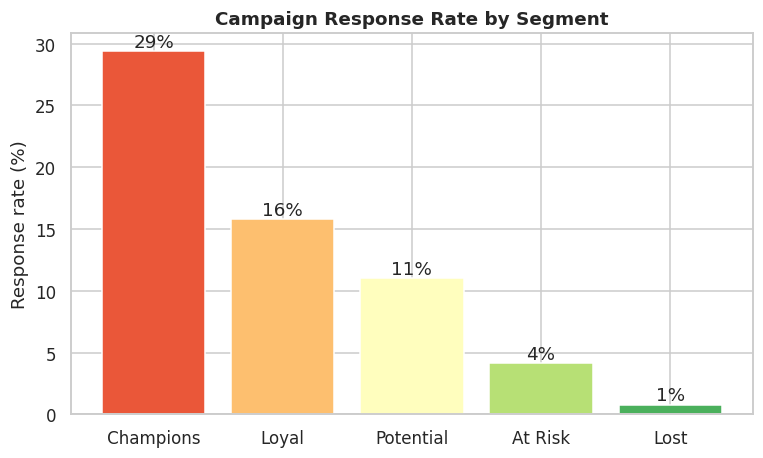

In [10]:
resp = df.groupby('RFM_Segment')['Response'].mean().reindex(order)*100
fig, ax = plt.subplots(figsize=(8,4.5))
bars=ax.bar(resp.index,resp.values,color=sns.color_palette('RdYlGn_r',5)[::-1])
ax.set_title('Campaign Response Rate by Segment', weight='bold'); ax.set_ylabel('Response rate (%)')
for b,v in zip(bars,resp.values): ax.text(b.get_x()+b.get_width()/2,v,f'{v:.0f}%',ha='center',va='bottom')
plt.show()

## 8. Statistical Tests — confirming the patterns are real

Rule: **p < 0.05** = the difference is real, not random.

In [11]:
print("Test                                  Result")
r=df[df.Response==1]['Income']; nr=df[df.Response==0]['Income']
t,p=stats.ttest_ind(r,nr,equal_var=False)
print(f"T-test Income (resp vs not)        {r.mean():.0f} vs {nr.mean():.0f}  p={p:.1e} {'SIG' if p<.05 else 'ns'}")

r=df[df.Response==1]['TotalSpend']; nr=df[df.Response==0]['TotalSpend']
t,p=stats.ttest_ind(r,nr,equal_var=False)
print(f"T-test Spend  (resp vs not)        {r.mean():.0f} vs {nr.mean():.0f}  p={p:.1e} {'SIG' if p<.05 else 'ns'}")

g=[x['TotalSpend'].values for _,x in df.groupby('Education')]
f,p=stats.f_oneway(*g); print(f"ANOVA  Spend across Education       F={f:.1f}  p={p:.1e} {'SIG' if p<.05 else 'ns'}")

chi2,p,_,_=stats.chi2_contingency(pd.crosstab(df.HasChildren,df.Response))
print(f"Chi2   Response vs HasChildren      chi2={chi2:.1f}  p={p:.1e} {'SIG' if p<.05 else 'ns'}")

rho,p=stats.pearsonr(df.Income,df.TotalSpend); print(f"Pearson Income vs Spend             r={rho:.2f}  p={p:.1e}")
rho,p=stats.pearsonr(df.NumWebVisitsMonth,df.NumWebPurchases); print(f"Pearson WebVisits vs WebPurchases   r={rho:.2f}  p={p:.1e}")

Test                                  Result
T-test Income (resp vs not)        60052 vs 50282  p=1.3e-12 SIG
T-test Spend  (resp vs not)        987 vs 539  p=2.9e-24 SIG
ANOVA  Spend across Education       F=16.6  p=1.1e-10 SIG
Chi2   Response vs HasChildren      chi2=93.1  p=5.0e-22 SIG
Pearson Income vs Spend             r=0.81  p=0.0e+00
Pearson WebVisits vs WebPurchases   r=-0.06  p=7.8e-03


**Insights from the tests:**
- Responders earn **$60K vs $50K** and spend **$987 vs $539** — both highly significant. Campaign targeting should be **income/spend based**.
- Having children is strongly linked to *not* responding (χ² = 93, p ≈ 5e-22).
- **Surprising:** web visits and web purchases are slightly **negatively** correlated (r = -0.06). More site visits ≠ more buying → possible **website friction / poor conversion**, worth a UX audit.

## 9. Key Business Insights

| # | Finding | Number |
|---|---------|--------|
| 1 | Wine dominates spending | **~50%** of all revenue |
| 2 | Champions drive the business | **24%** of customers → **49%** of revenue |
| 3 | Response is concentrated | Champions **29%** vs Lost **1%** |
| 4 | Income predicts value | r = **0.81** with spend |
| 5 | Children suppress spend | childless customers spend far more |
| 6 | Web traffic ≠ web sales | r = **-0.06** (conversion problem) |

## 10. Business Recommendations

1. **Stop mass-blasting campaigns.** Target Champions + Loyal (response 16–29%); exclude Lost/At-Risk (1–4%) to cut wasted spend.
2. **Build a wine-led loyalty program** — it's half the revenue; bundle fruits/sweets/gold around it.
3. **Win-back, don't acquire-blind** — design a separate low-cost reactivation offer for "At Risk" before they become "Lost".
4. **Target childless, higher-income households** for premium campaigns; use a different, value-focused message for families.
5. **Audit the website** — high visits with low purchases signals friction; fixing conversion is cheaper than buying more traffic.

## 11. Tools Used
`Python` · `Pandas` · `NumPy` · `Matplotlib` · `Seaborn` · `SciPy` · `scikit-learn (KMeans, StandardScaler)`
